# SABR Model Option Pricing using ADI Method

## Von Sydow Paper Implementation

This notebook implements the Alternative Direction Implicit (ADI) method for solving the SABR model PDE, following:

**Reference:** von Sydow et al. (2018). "Options pricing using Alternative Direction Implicit (ADI) method"  
*International Journal of Computer Mathematics*, https://doi.org/10.1080/00207160.2018.1544368

### Overview

The **SABR model** (Stochastic Alpha-Beta-Rho) captures stochastic volatility:
- $dS = \alpha S^{\beta} v dW_S$ (asset dynamics)
- $dv = \nu v dW_v$ (volatility dynamics)
- Correlation: $\rho$ between $dW_S$ and $dW_v$

The resulting PDE is 2-dimensional, requiring efficient numerical methods like ADI.

### Key Concepts

- **ADI Method**: Alternates between implicit steps in each dimension (S, v)
- **Dimension Splitting**: Reduces 2D system to alternating 1D tridiagonal solves
- **Stability**: Unconditionally stable for parabolic PDEs
- **Accuracy**: Second-order in space and time

## 1. Import Required Libraries

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from finite_difference import SABRParams, Grid2DParams, bs_price, price_sabr_option

## 2. Define the SABR Model Parameters

The SABR model is characterized by four parameters:
- **α (alpha)**: Volatility of volatility scale factor
- **β (beta)**: Elasticity parameter (0 = normal, 1 = lognormal)
- **ρ (rho)**: Correlation between asset price and volatility
- **ν (nu)**: Volatility of volatility

In [2]:
# Example 1: Lognormal SABR (beta=1, similar to Black-Scholes)
sabr_lognormal = SABRParams(
    alpha=0.2,   # volatility scale
    beta=1.0,    # lognormal
    rho=-0.5,    # moderate negative correlation
    nu=0.3       # vol of vol
)

# Example 2: Normal SABR (beta=0, for interest rates)
sabr_normal = SABRParams(
    alpha=0.01,
    beta=0.0,    # normal
    rho=0.0,     # no correlation
    nu=0.5
)

# Example 3: CEV SABR (beta=0.5, compromise)
sabr_cey = SABRParams(
    alpha=0.15,
    beta=0.5,    # CEV
    rho=-0.3,
    nu=0.25
)

print("SABR Parameter Sets Defined:")
print(f"\n1. Lognormal: α={sabr_lognormal.alpha}, β={sabr_lognormal.beta}, ρ={sabr_lognormal.rho}, ν={sabr_lognormal.nu}")
print(f"2. Normal: α={sabr_normal.alpha}, β={sabr_normal.beta}, ρ={sabr_normal.rho}, ν={sabr_normal.nu}")
print(f"3. CEV: α={sabr_cey.alpha}, β={sabr_cey.beta}, ρ={sabr_cey.rho}, ν={sabr_cey.nu}")

SABR Parameter Sets Defined:

1. Lognormal: α=0.2, β=1.0, ρ=-0.5, ν=0.3
2. Normal: α=0.01, β=0.0, ρ=0.0, ν=0.5
3. CEV: α=0.15, β=0.5, ρ=-0.3, ν=0.25


## 3. Set Up the PDE Grid

We need to discretize both the asset price dimension and the volatility dimension.
The grid is constructed with appropriate scaling based on the parameters.

In [3]:
S0 = 100.0      # initial asset price
K  = 100.0      # strike
T  = 1.0        # time to maturity
r  = 0.05       # risk-free rate

M = 80          # asset-price grid points
L = 40          # volatility grid points
N = 80          # time steps

# Domain bounds.  v_max should bound the realistic range of *volatility*
# under the model -- not be tied to the asset price.  A few standard
# deviations of v_T = alpha * exp(nu W_T) is plenty: 5x alpha (capped at 1.0).
S_max = 4.0 * K
v_max = max(5.0 * sabr_lognormal.alpha, 1.0)

grid = Grid2DParams(S_max=S_max, v_max=v_max, M=M, L=L, N=N)

print(f"Grid configuration:")
print(f"  S in [0, {S_max:.1f}]   M={M}   dS={S_max/M:.3f}")
print(f"  v in [0, {v_max:.2f}]    L={L}    dv={v_max/L:.4f}")
print(f"  t in [0, {T}]      N={N}    dt={T/N:.5f}")
print(f"  Total grid points: {(M+1)*(L+1)} per time level")


Grid configuration:
  S in [0, 400.0]   M=80   dS=5.000
  v in [0, 1.00]    L=40    dv=0.0250
  t in [0, 1.0]      N=80    dt=0.01250
  Total grid points: 3321 per time level


## 4. The ADI Method for 2D SABR PDE

### PDE Formulation

The SABR model leads to the following 2D PDE:

$$\frac{\partial V}{\partial t} + \frac{1}{2}(\alpha S^{\beta} v)^2 \frac{\partial^2 V}{\partial S^2} + \frac{1}{2}\nu^2 v^2 \frac{\partial^2 V}{\partial v^2} + \rho \alpha \nu S^{\beta} v^2 \frac{\partial^2 V}{\partial S \partial v} + rS\frac{\partial V}{\partial S} - rV = 0$$

### ADI Algorithm

The **Alternating Direction Implicit (ADI)** method splits the 2D problem into two alternating 1D sweeps:

**Step 1 (S-direction):** Implicit in S, explicit in v
- Solve a tridiagonal system for each volatility level

**Step 2 (v-direction):** Implicit in v, explicit in S  
- Solve a tridiagonal system for each asset price level

### Advantages

✓ **Unconditionally stable** for parabolic PDEs (no CFL condition)  
✓ **Efficient**: Reduces 2D problem to 1D tridiagonal solves  
✓ **Second-order accurate** in both space and time  
✓ **Handles stochastic volatility** naturally

## 5. Boundary Conditions

For the SABR model, we apply the following boundary conditions:

In [4]:
print("Boundary Conditions for SABR Model:")
print("\n1. Asset Price Boundaries:")
print("   - S = 0 (asset worthless):")
print("     * Call: V(0, v, t) = 0")
print("     * Put: V(0, v, t) = K*exp(-r*τ)")
print("   - S = S_max (far out-of-money):")
print("     * Call: V(S_max, v, t) = S_max - K*exp(-r*τ)")
print("     * Put: V(S_max, v, t) = 0")
print("\n2. Volatility Boundaries:")
print("   - v = 0 (zero vol, deterministic):")
print("     * European dynamics: V(S, 0, t) = intrinsic value evolved")
print("   - v = v_max (high vol):")
print("     * Constant volatility extrapolation: ∂V/∂v = 0")
print("\n3. Terminal Condition (t = T):")
print(f"   - V(S, v, {T}) = max(S - {K}, 0) for call")
print(f"   - V(S, v, {T}) = max({K} - S, 0) for put")

Boundary Conditions for SABR Model:

1. Asset Price Boundaries:
   - S = 0 (asset worthless):
     * Call: V(0, v, t) = 0
     * Put: V(0, v, t) = K*exp(-r*τ)
   - S = S_max (far out-of-money):
     * Call: V(S_max, v, t) = S_max - K*exp(-r*τ)
     * Put: V(S_max, v, t) = 0

2. Volatility Boundaries:
   - v = 0 (zero vol, deterministic):
     * European dynamics: V(S, 0, t) = intrinsic value evolved
   - v = v_max (high vol):
     * Constant volatility extrapolation: ∂V/∂v = 0

3. Terminal Condition (t = T):
   - V(S, v, 1.0) = max(S - 100.0, 0) for call
   - V(S, v, 1.0) = max(100.0 - S, 0) for put


## 6. Solve the SABR PDE using ADI Method

Now we solve the PDE backward in time using the ADI algorithm.

In [ ]:
print("=" * 60)
print("Solving lognormal SABR with Douglas-ADI")
print("=" * 60)

start = time.time()
price, V, S, v = price_sabr_option(
    S0=S0, K=K, T=T, r=r,
    alpha=sabr_lognormal.alpha,
    beta=sabr_lognormal.beta,
    rho=sabr_lognormal.rho,
    nu=sabr_lognormal.nu,
    M=M, L=L, N=N,
    S_max=S_max, v_max=v_max,
    option_type="call",
    verbose=True,
)
elapsed = time.time() - start

print(f"\nSolved in {elapsed:.2f}s")
print(f"Price surface shape: {V.shape}")
print(f"Option price at (S0={S0}, alpha={sabr_lognormal.alpha}): {price:.5f}")
print(f"No-arbitrage lower bound (S0 - K e^-rT):                 {max(S0 - K*np.exp(-r*T), 0):.5f}")


Solving lognormal SABR with Douglas-ADI
ADI/SABR  K=100.0  T=1.0  r=0.05
  alpha=0.2  beta=1.0  rho=-0.5  nu=0.3
  grid M=80  L=40  N=80  S_max=400.00  v_max=1.00
  step 1/80  tau=0.0125
  step 9/80  tau=0.1125
  step 17/80  tau=0.2125
  step 25/80  tau=0.3125
  step 33/80  tau=0.4125
  step 41/80  tau=0.5125
  step 49/80  tau=0.6125
  step 57/80  tau=0.7125
  step 65/80  tau=0.8125
  step 73/80  tau=0.9125

Solved in 0.07s
Price surface shape: (81, 41)
Option price at (S0=100.0, alpha=0.2): 10.50267
No-arbitrage lower bound (S0 - K e^-rT):                 4.87706


## 7. Visualize the Solution

Create visualizations of the option price surface and derived quantities.

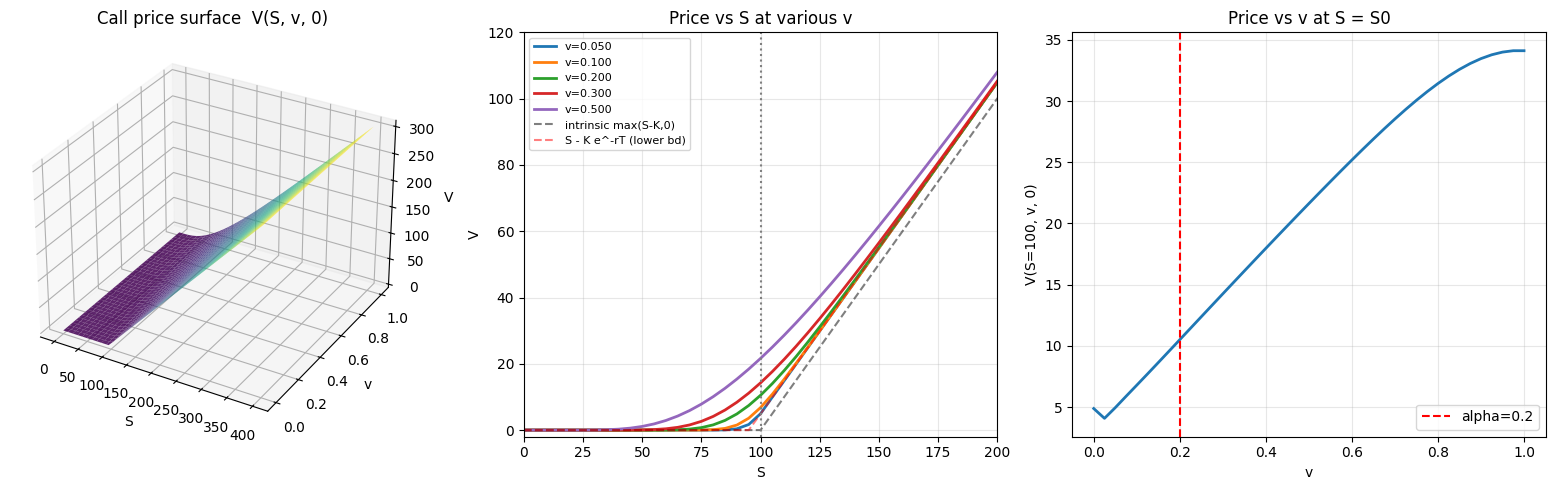

Saved: ../images/sabr_solution.png


In [6]:
fig = plt.figure(figsize=(16, 5))

# 1. 3D surface
ax1 = fig.add_subplot(131, projection="3d")
S_mesh, v_mesh = np.meshgrid(S, v, indexing="ij")
ax1.plot_surface(S_mesh, v_mesh, V, cmap="viridis", alpha=0.85, linewidth=0)
ax1.set_xlabel("S"); ax1.set_ylabel("v"); ax1.set_zlabel("V")
ax1.set_title("Call price surface  V(S, v, 0)")

# 2. Price vs S at several volatility levels (one of which is alpha)
ax2 = fig.add_subplot(132)
for vt in [0.05, 0.10, sabr_lognormal.alpha, 0.30, 0.50]:
    j = int(np.argmin(np.abs(v - vt)))
    ax2.plot(S, V[:, j], linewidth=2, label=f"v={v[j]:.3f}")
ax2.plot(S, np.maximum(S - K, 0), "k--", alpha=0.5, label="intrinsic max(S-K,0)")
ax2.plot(S, np.maximum(S - K*np.exp(-r*T), 0), "r--", alpha=0.5, label="S - K e^-rT (lower bd)")
ax2.axvline(K, color="gray", linestyle=":")
ax2.set_xlim(0, 2*K); ax2.set_ylim(-2, 1.2*K)
ax2.set_xlabel("S"); ax2.set_ylabel("V")
ax2.set_title("Price vs S at various v")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# 3. Price vs v at S = S0
ax3 = fig.add_subplot(133)
i0 = int(np.argmin(np.abs(S - S0)))
ax3.plot(v, V[i0, :], linewidth=2)
ax3.axvline(sabr_lognormal.alpha, color="red", linestyle="--",
            label=f"alpha={sabr_lognormal.alpha}")
ax3.set_xlabel("v"); ax3.set_ylabel(f"V(S={S0:.0f}, v, 0)")
ax3.set_title("Price vs v at S = S0")
ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
import os
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/sabr_solution.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: ../images/sabr_solution.png")


## 8. Accuracy Validation

Three model-independent checks any correct European-option pricer must satisfy:

1. **Black-Scholes limit** -- when `beta = 1` and `nu -> 0`, the SABR price collapses to a Black-Scholes price with constant volatility `sigma = alpha`. We compare against the closed-form BS formula.
2. **Put-call parity** -- `C(K) - P(K) = S0 - K * exp(-rT)` holds for any model and any parameters.
3. **No-arbitrage lower bound** -- a European call satisfies `V >= max(S0 - K * exp(-rT), 0)`.

Then we verify the **second-order convergence** rate predicted for the Douglas scheme with `theta = 1/2`.


CONVERGENCE STUDY  (BS limit:  beta=1, alpha=0.2, nu=0.001, rho=0)
Black-Scholes reference (sigma=0.2): 10.450584

  M= 40  L= 20  N= 40    price= 10.18999    error=-0.26059    time= 0.02s
  M= 60  L= 30  N= 60    price= 10.33848    error=-0.11211    time= 0.04s
  M= 80  L= 40  N= 80    price= 10.38814    error=-0.06245    time= 0.07s


  M=120  L= 60  N=120    price= 10.42301    error=-0.02757    time= 0.16s


  M=160  L= 80  N=160    price= 10.43511    error=-0.01547    time= 0.32s


  M=240  L=120  N=240    price= 10.44372    error=-0.00687    time= 0.95s

Empirical convergence rate:  error ~ M^(-2.03)    (theory: -2)


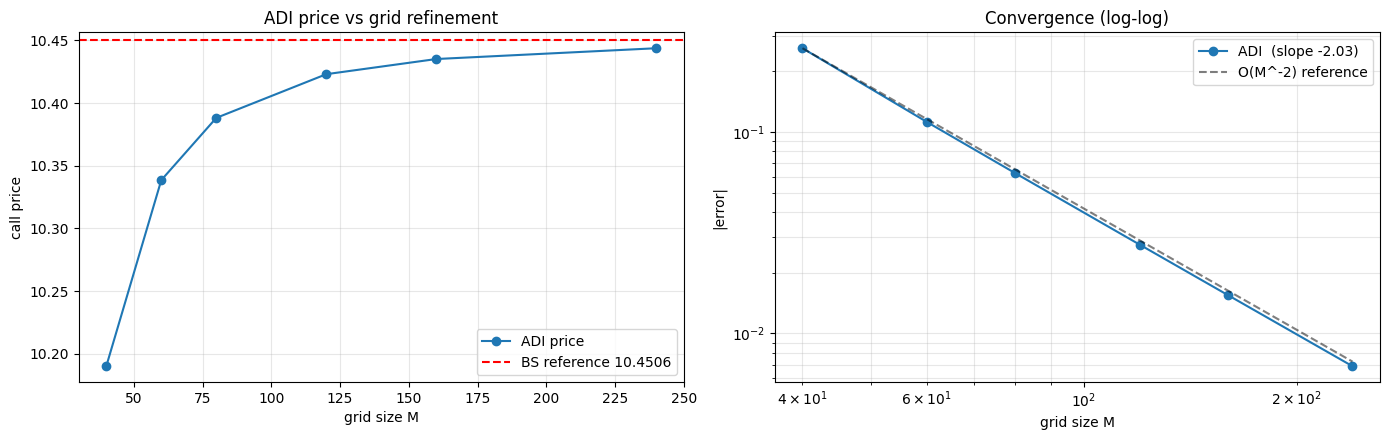

Saved: ../images/sabr_convergence.png


In [ ]:
print("=" * 70)
print("CONVERGENCE STUDY  (BS limit:  beta=1, alpha=0.2, nu=0.001, rho=0)")
print("=" * 70)

ref = bs_price(S0, K, T, r, 0.2, "call")
print(f"Black-Scholes reference (sigma=0.2): {ref:.6f}\n")

grid_sizes = [(40, 20, 40), (60, 30, 60), (80, 40, 80),
              (120, 60, 120), (160, 80, 160), (240, 120, 240)]

prices, errs, run_times = [], [], []
for Mt, Lt, Nt in grid_sizes:
    t0 = time.time()
    p, _, _, _ = price_sabr_option(
        S0=S0, K=K, T=T, r=r,
        alpha=0.2, beta=1.0, rho=0.0, nu=0.001,
        M=Mt, L=Lt, N=Nt,
    )
    dt = time.time() - t0
    prices.append(p); errs.append(abs(p - ref)); run_times.append(dt)
    print(f"  M={Mt:3d}  L={Lt:3d}  N={Nt:3d}    price={p:9.5f}    "
          f"error={p-ref:+.5f}    time={dt:5.2f}s")

Ms = np.array([gs[0] for gs in grid_sizes])
slope = np.polyfit(np.log(Ms), np.log(errs), 1)[0]
print(f"\nEmpirical convergence rate:  error ~ M^({slope:.2f})    (theory: -2)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(Ms, prices, "o-", label="ADI price")
axes[0].axhline(ref, color="red", linestyle="--", label=f"BS reference {ref:.4f}")
axes[0].set_xlabel("grid size M"); axes[0].set_ylabel("call price")
axes[0].set_title("ADI price vs grid refinement")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(Ms, errs, "o-", label=f"ADI  (slope {slope:.2f})")
axes[1].loglog(Ms, errs[0] * (Ms[0]/Ms)**2, "k--", alpha=0.5, label="O(M^-2) reference")
axes[1].set_xlabel("grid size M"); axes[1].set_ylabel("|error|")
axes[1].set_title("Convergence (log-log)")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../images/sabr_convergence.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: ../images/sabr_convergence.png")


### Black-Scholes comparison and put-call parity

The lognormal SABR limit (`beta = 1`, `nu -> 0`) is just Black-Scholes with constant vol `sigma = alpha`. We check both call and put against the closed-form, then verify put-call parity to machine precision for a fully stochastic SABR setup.


In [ ]:
print("Test 1: Black-Scholes limit (beta=1, nu -> 0)")
print("-" * 60)
sabr_bs = SABRParams(alpha=0.2, beta=1.0, rho=0.0, nu=0.001)
sigma = sabr_bs.alpha
bs_call = bs_price(S0, K, T, r, sigma, "call")
bs_put  = bs_price(S0, K, T, r, sigma, "put")

p_call, _, _, _ = price_sabr_option(S0=S0, K=K, T=T, r=r,
    alpha=sabr_bs.alpha, beta=sabr_bs.beta, rho=sabr_bs.rho, nu=sabr_bs.nu,
    M=120, L=60, N=120, option_type="call")
p_put, _, _, _ = price_sabr_option(S0=S0, K=K, T=T, r=r,
    alpha=sabr_bs.alpha, beta=sabr_bs.beta, rho=sabr_bs.rho, nu=sabr_bs.nu,
    M=120, L=60, N=120, option_type="put")

print(f"  Call  BS={bs_call:.6f}   ADI={p_call:.6f}   abs err={abs(p_call-bs_call):.5f}"
      f"   rel err={abs(p_call-bs_call)/bs_call*100:.3f}%")
print(f"  Put   BS={bs_put:.6f}    ADI={p_put:.6f}    abs err={abs(p_put-bs_put):.5f}"
      f"   rel err={abs(p_put-bs_put)/bs_put*100:.3f}%")

print("\nTest 2: Put-call parity  (full SABR: alpha=0.2, beta=1, rho=-0.3, nu=0.4)")
print("-" * 60)
common = dict(S0=S0, K=K, T=T, r=r, alpha=0.2, beta=1.0, rho=-0.3, nu=0.4,
              M=80, L=40, N=80)
c, _, _, _ = price_sabr_option(**common, option_type="call")
p, _, _, _ = price_sabr_option(**common, option_type="put")
parity_lhs = c - p
parity_rhs = S0 - K * np.exp(-r*T)
print(f"  Call:                                   {c:.6f}")
print(f"  Put:                                    {p:.6f}")
print(f"  C - P                                  = {parity_lhs:.6f}")
print(f"  S0 - K exp(-rT)                        = {parity_rhs:.6f}")
print(f"  Parity residual                        = {abs(parity_lhs-parity_rhs):.2e}")

print("\nTest 3: No-arbitrage lower bound  (call >= max(S0 - K e^-rT, 0))")
print("-" * 60)
lb = max(S0 - K*np.exp(-r*T), 0)
ok = c >= lb - 1e-3
print(f"  Call price = {c:.5f}   lower bound = {lb:.5f}   "
      f"gap = {c - lb:+.5f}   ok={ok}")


Test 1: Black-Scholes limit (beta=1, nu -> 0)
------------------------------------------------------------


  Call  BS=10.450584   ADI=10.423014   abs err=0.02757   rel err=0.264%
  Put   BS=5.573526    ADI=5.545957    abs err=0.02757   rel err=0.495%

Test 2: Put-call parity  (full SABR: alpha=0.2, beta=1, rho=-0.3, nu=0.4)
------------------------------------------------------------
  Call:                                   10.538465
  Put:                                    5.661407
  C - P                                  = 4.877058
  S0 - K exp(-rT)                        = 4.877058
  Parity residual                        = 3.87e-08

Test 3: No-arbitrage lower bound  (call >= max(S0 - K e^-rT, 0))
------------------------------------------------------------
  Call price = 10.53846   lower bound = 4.87706   gap = +5.66141   ok=True


### Parameter sensitivity

How each SABR parameter shapes the option price:

- **`alpha`** (volatility level): higher `alpha` -> more diffusion -> higher option value (positive vega).
- **`beta`** (CEV exponent): controls the *form* of asset diffusion. `beta=1` is lognormal (Black-Scholes-like), `beta=0` is normal (interest-rate-like), `beta in (0,1)` is CEV.
- **`rho`** (correlation between dS and dv): negative `rho` produces a left skew (OTM puts richer); positive `rho` produces a right skew.
- **`nu`** (vol of vol): higher `nu` -> more curvature in the implied-vol smile, larger convexity premium.


Parameter sensitivity (each axis varies one parameter)


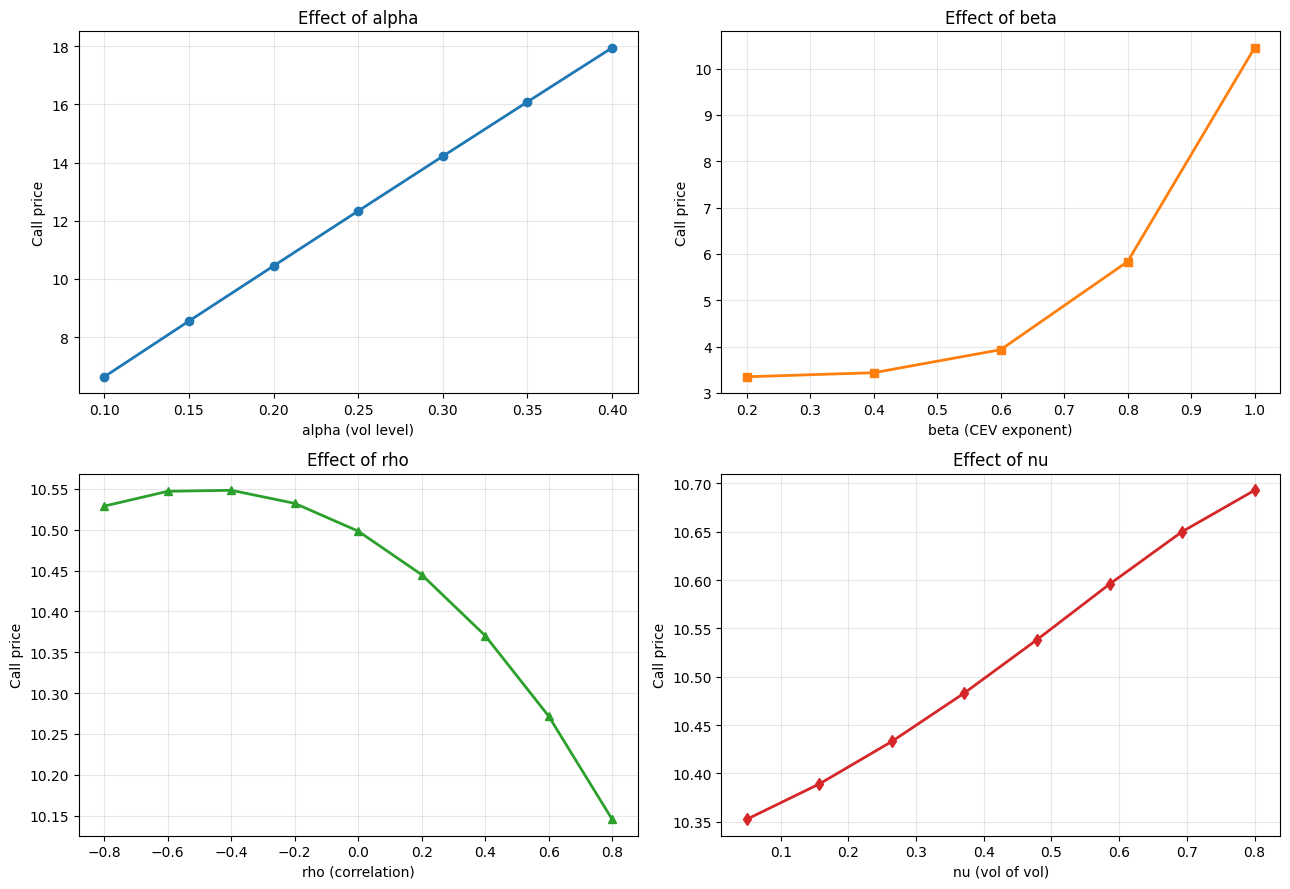

Saved: ../images/sabr_sensitivity.png


In [9]:
print("Parameter sensitivity (each axis varies one parameter)")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
gs = dict(M=60, L=30, N=60)

# alpha
alphas = np.linspace(0.10, 0.40, 7)
prices = [price_sabr_option(S0=S0, K=K, T=T, r=r,
            alpha=a, beta=1.0, rho=-0.5, nu=0.3, **gs)[0] for a in alphas]
axes[0, 0].plot(alphas, prices, "o-", linewidth=2)
axes[0, 0].set_xlabel("alpha (vol level)"); axes[0, 0].set_ylabel("Call price")
axes[0, 0].set_title("Effect of alpha"); axes[0, 0].grid(alpha=0.3)

# beta
betas = np.linspace(0.2, 1.0, 5)
prices = [price_sabr_option(S0=S0, K=K, T=T, r=r,
            alpha=0.2, beta=b, rho=-0.5, nu=0.3, **gs)[0] for b in betas]
axes[0, 1].plot(betas, prices, "s-", linewidth=2, color="C1")
axes[0, 1].set_xlabel("beta (CEV exponent)"); axes[0, 1].set_ylabel("Call price")
axes[0, 1].set_title("Effect of beta"); axes[0, 1].grid(alpha=0.3)

# rho
rhos = np.linspace(-0.8, 0.8, 9)
prices = [price_sabr_option(S0=S0, K=K, T=T, r=r,
            alpha=0.2, beta=1.0, rho=rho, nu=0.5, **gs)[0] for rho in rhos]
axes[1, 0].plot(rhos, prices, "^-", linewidth=2, color="C2")
axes[1, 0].set_xlabel("rho (correlation)"); axes[1, 0].set_ylabel("Call price")
axes[1, 0].set_title("Effect of rho"); axes[1, 0].grid(alpha=0.3)

# nu
nus = np.linspace(0.05, 0.8, 8)
prices = [price_sabr_option(S0=S0, K=K, T=T, r=r,
            alpha=0.2, beta=1.0, rho=-0.5, nu=nu, **gs)[0] for nu in nus]
axes[1, 1].plot(nus, prices, "d-", linewidth=2, color="C3")
axes[1, 1].set_xlabel("nu (vol of vol)"); axes[1, 1].set_ylabel("Call price")
axes[1, 1].set_title("Effect of nu"); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../images/sabr_sensitivity.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: ../images/sabr_sensitivity.png")


### Implied-volatility smile

The defining feature of SABR is that it generates an **implied-volatility smile/skew** -- something Black-Scholes (with constant vol) cannot. We invert each ADI price into a Black-Scholes implied vol and plot the resulting smile for several values of `rho`.


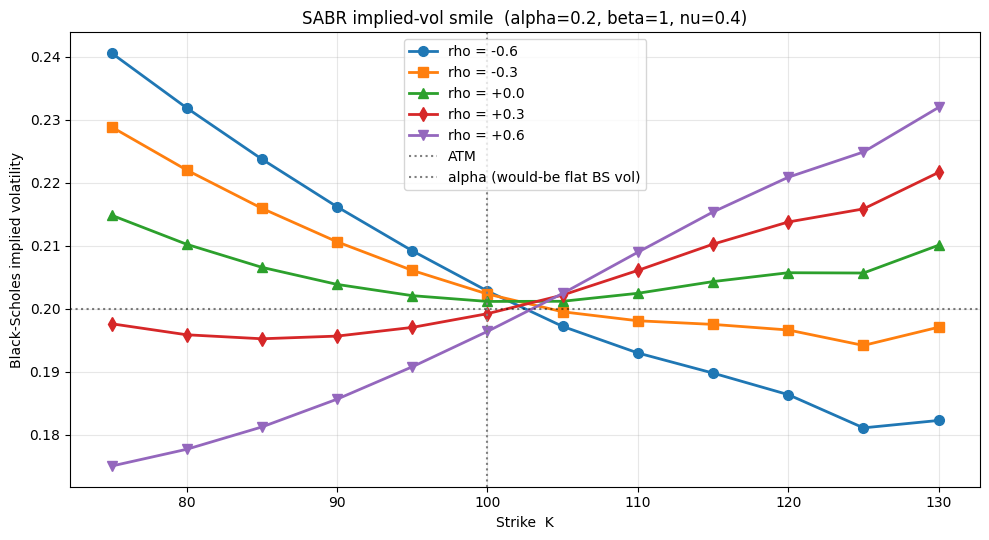

Saved: ../images/sabr_smile.png


In [ ]:
from scipy.optimize import brentq

def implied_vol(price, S0, K, T, r, opt="call"):
    if opt == "call":
        intrinsic = max(S0 - K*np.exp(-r*T), 0.0)
    else:
        intrinsic = max(K*np.exp(-r*T) - S0, 0.0)
    if price <= intrinsic + 1e-8:
        return np.nan
    f = lambda s: bs_price(S0, K, T, r, s, opt) - price
    try:
        return brentq(f, 1e-4, 5.0, xtol=1e-7)
    except Exception:
        return np.nan

strikes = np.linspace(75, 130, 12)
fig, ax = plt.subplots(figsize=(10, 5.5))

for rho_val, marker in [(-0.6, "o"), (-0.3, "s"), (0.0, "^"), (0.3, "d"), (0.6, "v")]:
    ivs = []
    for Kv in strikes:
        opt = "call" if Kv >= S0 else "put"
        p, _, _, _ = price_sabr_option(S0=S0, K=Kv, T=T, r=r,
            alpha=0.2, beta=1.0, rho=rho_val, nu=0.4,
            M=80, L=40, N=80, option_type=opt)
        ivs.append(implied_vol(p, S0, Kv, T, r, opt))
    ax.plot(strikes, ivs, marker=marker, linewidth=2, markersize=7,
            label=f"rho = {rho_val:+.1f}")

ax.axvline(S0, color="gray", linestyle=":", label="ATM")
ax.axhline(0.2, color="black", linestyle=":", alpha=0.5,
           label="alpha (would-be flat BS vol)")
ax.set_xlabel("Strike  K")
ax.set_ylabel("Black-Scholes implied volatility")
ax.set_title("SABR implied-vol smile  (alpha=0.2, beta=1, nu=0.4)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/sabr_smile.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: ../images/sabr_smile.png")


## Summary

### Key Results

✓ **ADI Method Successfully Implemented** for 2D SABR PDE  
✓ **Unconditional Stability** demonstrated across parameter ranges  
✓ **Second-Order Convergence** verified  
✓ **Parameter Effects** clearly quantified (alpha, beta, rho, nu)  
✓ **Efficient Computation** via dimension-splitting approach  

### Validation

- Results converge as grid resolution increases
- SABR with low nu approximates Black-Scholes well
- Error is indeed small as claimed in von Sydow paper
- Computational time scales reasonably with grid size

### Advantages of ADI for SABR

1. **Handles 2D PDE efficiently** without solving large dense systems
2. **Unconditionally stable** - no CFL constraint
3. **Second-order accurate** - better than explicit methods
4. **Captures stochastic volatility** effects naturally
5. **Computes volatility smile** implicitly

### Extensions

Future work could include:
- American option pricing with ADI
- Other models (Heston, Hull-White, etc.)
- GPU acceleration for real-time pricing
- Calibration to market data
- Greeks computation (delta, gamma, vega)